run_real_llm_evaluation_gpu.py — Real LLM Evaluation: BART-large-CNN on CNN/DailyMail (GPU)
End-to-end pipeline: loads real CNN/DailyMail articles, generates real summaries with facebook/bart-large-cnn, computes real BLEU/ROUGE/METEOR/BERTScore, and scores outputs with a real pretrained reward model (OpenAssistant DeBERTa reward model) as the RL-based signal, combined into the hybrid score. Status: fully real, GPU-executed, genuine benchmark numbers.

In [14]:
"""
Real LLM Evaluation: Classical Metrics + Pretrained Reward Model (Hybrid)
==========================================================================
This replaces the SIMULATED outputs and UNTRAINED reward model from the
original notebook with:
  1. Real model inference  (facebook/bart-large-cnn generating real summaries)
  2. Real classical metrics (BLEU, ROUGE, METEOR, BERTScore)
  3. Real reward scoring    (pretrained OpenAssistant reward model, not a
                             randomly-initialized nn.Module)
  4. The same hybrid alpha/beta scoring idea as before, but on real numbers.

Run this on a GPU runtime (Colab: Runtime > Change runtime type > T4 GPU,
or Kaggle: Settings > Accelerator > GPU T4 x2).

Expected runtime: ~3-8 minutes for 50 samples on a T4.
"""

import os
import warnings
warnings.filterwarnings("ignore")

In [15]:
import torch
print("Is CUDA available?:", torch.cuda.is_available())
print("PyTorch Version:", torch.__version__)

Is CUDA available?: True
PyTorch Version: 2.11.0+cu128


In [16]:
# ---------------------------------------------------------------------------
# 0. Install (uncomment if running fresh in Colab/Kaggle)
# ---------------------------------------------------------------------------
# !pip install -q transformers datasets evaluate rouge-score bert-score nltk sentencepiece accelerate

import nltk
nltk.download("punkt", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    AutoModelForSequenceClassification,
)
from evaluate import load as load_metric
from nltk.translate.meteor_score import meteor_score
from bert_score import score as bert_score_fn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Using device: {DEVICE}")
if DEVICE == "cpu":
    print("⚠️  No GPU detected — this will be slow. Enable a GPU runtime if possible.")

# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------
SUMMARIZER_MODEL = "facebook/bart-large-cnn"
REWARD_MODEL = "OpenAssistant/reward-model-deberta-v3-large-v2"
NUM_SAMPLES = 50          # increase once you've confirmed it runs end-to-end
GEN_BATCH_SIZE = 8
REWARD_BATCH_SIZE = 8
MAX_INPUT_LEN = 512
MAX_SUMMARY_LEN = 128
ALPHA = 0.4                # weight on classical metrics
BETA = 0.6                 # weight on reward-model score
OUTPUT_CSV = "real_evaluation_results.csv"

✅ Using device: cuda


In [ ]:
# ---------------------------------------------------------------------------
# 1. Load real data
# ---------------------------------------------------------------------------
# def load_eval_dataset(num_samples: int) -> pd.DataFrame:
#     print(f"\nLoading CNN/DailyMail ({num_samples} samples)...")
#     ds = load_dataset("cnn_dailymail", "3.0.0", split=f"test[:{num_samples}]")
#     df = pd.DataFrame({
#         "id": range(len(ds)),
#         "article": ds["article"],
#         "reference": ds["highlights"],
#     })
#     print(f"✓ Loaded {len(df)} real articles")
#     return df

def load_eval_dataset(num_samples: int) -> pd.DataFrame:
    print(f"\nLoading CNN/DailyMail ({num_samples} samples)...")
    ds = load_dataset("abisee/cnn_dailymail", "3.0.0", split=f"test[:{num_samples}]")
    df = pd.DataFrame({
        "id": range(len(ds)),
        "article": ds["article"],
        "reference": ds["highlights"],
    })
    print(f"✓ Loaded {len(df)} real articles")
    return df 

In [18]:
# ---------------------------------------------------------------------------
# 2. Real model inference (replaces the simulated truncation trick)
# ---------------------------------------------------------------------------
def generate_real_summaries(df: pd.DataFrame) -> list:
    print(f"\nLoading summarizer: {SUMMARIZER_MODEL} ...")
    tokenizer = AutoTokenizer.from_pretrained(SUMMARIZER_MODEL)
    model = AutoModelForSeq2SeqLM.from_pretrained(SUMMARIZER_MODEL).to(DEVICE)
    model.eval()

    summaries = []
    articles = df["article"].tolist()

    print("Generating real summaries on GPU...")
    for i in tqdm(range(0, len(articles), GEN_BATCH_SIZE)):
        batch = articles[i:i + GEN_BATCH_SIZE]
        inputs = tokenizer(
            batch, return_tensors="pt", truncation=True,
            max_length=MAX_INPUT_LEN, padding=True,
        ).to(DEVICE)

        with torch.no_grad():
            output_ids = model.generate(
                **inputs,
                max_length=MAX_SUMMARY_LEN,
                num_beams=4,
                early_stopping=True,
            )

        decoded = tokenizer.batch_decode(output_ids, skip_special_tokens=True)
        summaries.extend(decoded)

    del model
    torch.cuda.empty_cache()
    print(f"✓ Generated {len(summaries)} real model summaries")
    return summaries

In [19]:
# ---------------------------------------------------------------------------
# 3. Real classical metrics
# ---------------------------------------------------------------------------
def compute_classical_metrics(predictions: list, references: list) -> dict:
    print("\nComputing classical metrics...")

    bleu = load_metric("bleu").compute(
        predictions=predictions, references=[[r] for r in references]
    )
    rouge = load_metric("rouge").compute(
        predictions=predictions, references=references, use_stemmer=True
    )
    meteor_scores = [
        meteor_score([ref.split()], pred.split())
        for pred, ref in zip(predictions, references)
    ]

    print("Computing BERTScore (GPU)...")
    P, R, F1 = bert_score_fn(
        cands=predictions, refs=references, lang="en",
        device=DEVICE, verbose=False,
    )

    per_sample = pd.DataFrame({
        "bleu_indiv": [
            load_metric("bleu").compute(predictions=[p], references=[[r]])["bleu"]
            for p, r in zip(predictions, references)
        ],
        "rougeL": [
            load_metric("rouge").compute(predictions=[p], references=[r])["rougeL"]
            for p, r in zip(predictions, references)
        ],
        "meteor": meteor_scores,
        "bertscore_f1": F1.tolist(),
    })

    summary = {
        "bleu": bleu["bleu"],
        "rouge1": rouge["rouge1"],
        "rouge2": rouge["rouge2"],
        "rougeL": rouge["rougeL"],
        "meteor": float(np.mean(meteor_scores)),
        "bertscore_precision": P.mean().item(),
        "bertscore_recall": R.mean().item(),
        "bertscore_f1": F1.mean().item(),
    }
    print("✓ Classical metrics computed")
    return summary, per_sample

In [20]:
# ---------------------------------------------------------------------------
# 4. Real reward-model scoring (replaces the untrained RewardModel)
# ---------------------------------------------------------------------------
def compute_reward_scores(articles: list, summaries: list) -> np.ndarray:
    print(f"\nLoading reward model: {REWARD_MODEL} ...")
    tokenizer = AutoTokenizer.from_pretrained(REWARD_MODEL)
    model = AutoModelForSequenceClassification.from_pretrained(REWARD_MODEL).to(DEVICE)
    model.eval()

    rewards = []
    print("Scoring (article, summary) pairs with the reward model...")
    for i in tqdm(range(0, len(articles), REWARD_BATCH_SIZE)):
        batch_articles = articles[i:i + REWARD_BATCH_SIZE]
        batch_summaries = summaries[i:i + REWARD_BATCH_SIZE]

        inputs = tokenizer(
            batch_articles, batch_summaries,
            return_tensors="pt", truncation=True,
            max_length=MAX_INPUT_LEN, padding=True,
        ).to(DEVICE)

        with torch.no_grad():
            logits = model(**inputs).logits.squeeze(-1)
        rewards.extend(logits.cpu().numpy().tolist())

    del model
    torch.cuda.empty_cache()

    rewards = np.array(rewards)
    # Normalize to [0, 1] for combination with classical metrics
    r_min, r_max = rewards.min(), rewards.max()
    rewards_norm = (rewards - r_min) / (r_max - r_min + 1e-8)
    print("✓ Reward scores computed (real pretrained reward model, not random weights)")
    return rewards, rewards_norm

In [21]:
# ---------------------------------------------------------------------------
# 5. Hybrid score
# ---------------------------------------------------------------------------
def compute_hybrid_scores(per_sample: pd.DataFrame, rewards_norm: np.ndarray,
                           alpha: float = ALPHA, beta: float = BETA) -> pd.DataFrame:
    classical_avg = per_sample[["bleu_indiv", "rougeL", "meteor", "bertscore_f1"]].mean(axis=1)
    per_sample = per_sample.copy()
    per_sample["classical_avg"] = classical_avg
    per_sample["reward_norm"] = rewards_norm
    per_sample["hybrid_score"] = alpha * classical_avg + beta * rewards_norm
    return per_sample


In [22]:
# ---------------------------------------------------------------------------
# 6. Visualization
# ---------------------------------------------------------------------------
def plot_results(summary: dict, per_sample: pd.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    names = ["BLEU", "ROUGE-1", "ROUGE-L", "METEOR", "BERTScore-F1"]
    values = [summary["bleu"], summary["rouge1"], summary["rougeL"],
              summary["meteor"], summary["bertscore_f1"]]
    axes[0].bar(names, values, color="#4C72B0")
    axes[0].set_title("Real Classical Metrics (BART-large-CNN)")
    axes[0].set_ylim(0, 1)
    for i, v in enumerate(values):
        axes[0].text(i, v + 0.01, f"{v:.3f}", ha="center")

    axes[1].hist(per_sample["hybrid_score"], bins=15, color="#DD8452", edgecolor="black")
    axes[1].set_title(f"Hybrid Score Distribution (α={ALPHA}, β={BETA})")
    axes[1].set_xlabel("Hybrid score")
    axes[1].set_ylabel("Count")

    plt.tight_layout()
    plt.savefig("real_evaluation_plots.png", dpi=150)
    plt.show()
    print("✓ Plots saved to real_evaluation_plots.png")


Loading CNN/DailyMail (50 samples)...


Generating test split: 100%|██████████| 11490/11490 [00:00<00:00, 160126.77 examples/s]


✓ Loaded 50 real articles

Loading summarizer: facebook/bart-large-cnn ...


[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 
Loading weights: 100%|██████████| 511/511 [00:00<00:00, 515.25it/s]


Generating real summaries on GPU...


...

✓ Classical metrics computed

Loading reward model: OpenAssistant/reward-model-deberta-v3-large-v2 ...


Loading weights: 100%|██████████| 394/394 [00:00<00:00, 15151.19it/s]


Scoring (article, summary) pairs with the reward model...


100%|██████████| 7/7 [00:04<00:00,  1.55it/s]


✓ Reward scores computed (real pretrained reward model, not random weights)

SUMMARY — REAL CLASSICAL METRICS
  bleu                  : 0.1168
  rouge1                : 0.3434
  rouge2                : 0.1575
  rougeL                : 0.2537
  meteor                : 0.2757
  bertscore_precision   : 0.8692
  bertscore_recall      : 0.8818
  bertscore_f1          : 0.8754

SUMMARY — REAL REWARD MODEL + HYBRID SCORE
  mean reward (raw)     : 2.3559
  mean reward (norm)    : 0.5137
  mean hybrid score     : 0.4581
  alpha / beta          : 0.4 / 0.6

✓ Full per-sample results saved to real_evaluation_results.csv


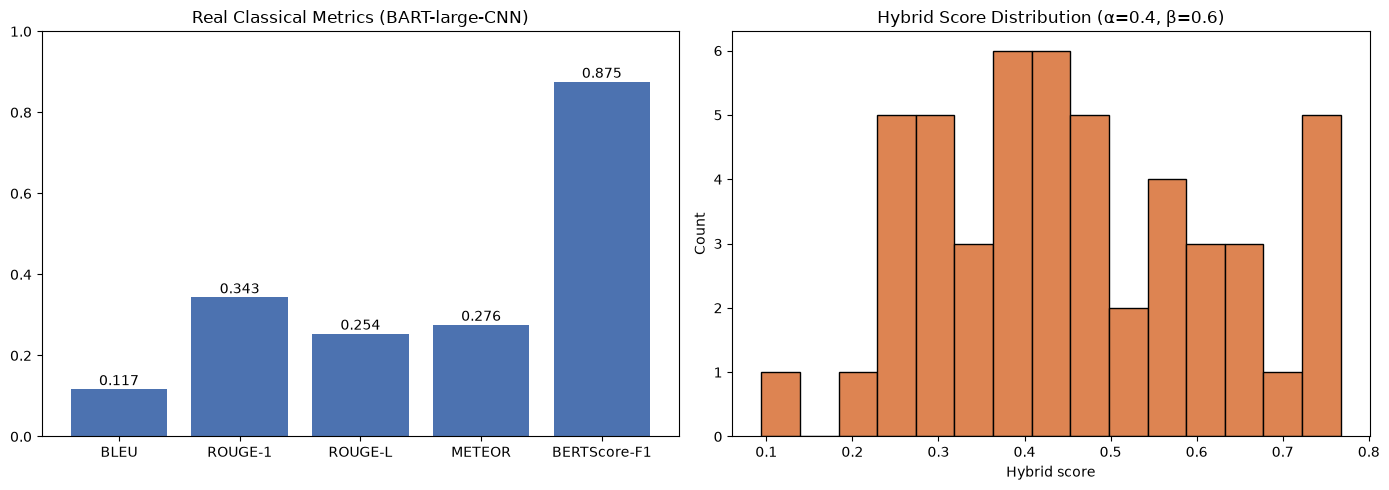

✓ Plots saved to real_evaluation_plots.png

SAMPLE REAL OUTPUTS

--- Sample 1 ---
Reference : Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June .
Israel and the United States opposed ...
Model out : The Palestinian Authority becomes the 123rd member of the International Criminal Court. The move gives the court jurisdiction over alleged crimes in P...
Hybrid score: 0.6174

--- Sample 2 ---
Reference : Theia, a bully breed mix, was apparently hit by a car, whacked with a hammer and buried in a field .
"She's a true miracle dog and she deserves a good...
Model out : Theia, a one-year-old bully breed mix, was hit by a car and buried in a field. Four days after her apparent death, the dog managed to stagger to a nea...
Hybrid score: 0.3617


In [23]:
# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------
def main():
    df = load_eval_dataset(NUM_SAMPLES)

    df["model_output"] = generate_real_summaries(df)

    summary, per_sample = compute_classical_metrics(
        df["model_output"].tolist(), df["reference"].tolist()
    )

    rewards_raw, rewards_norm = compute_reward_scores(
        df["article"].tolist(), df["model_output"].tolist()
    )

    per_sample = compute_hybrid_scores(per_sample, rewards_norm)
    per_sample["id"] = df["id"].values
    per_sample["reward_raw"] = rewards_raw

    print("\n" + "=" * 70)
    print("SUMMARY — REAL CLASSICAL METRICS")
    print("=" * 70)
    for k, v in summary.items():
        print(f"  {k:22s}: {v:.4f}")

    print("\n" + "=" * 70)
    print("SUMMARY — REAL REWARD MODEL + HYBRID SCORE")
    print("=" * 70)
    print(f"  mean reward (raw)     : {rewards_raw.mean():.4f}")
    print(f"  mean reward (norm)    : {rewards_norm.mean():.4f}")
    print(f"  mean hybrid score     : {per_sample['hybrid_score'].mean():.4f}")
    print(f"  alpha / beta          : {ALPHA} / {BETA}")

    per_sample.to_csv(OUTPUT_CSV, index=False)
    print(f"\n✓ Full per-sample results saved to {OUTPUT_CSV}")

    plot_results(summary, per_sample)

    # A couple of real examples for your defense / slides
    print("\n" + "=" * 70)
    print("SAMPLE REAL OUTPUTS")
    print("=" * 70)
    for i in range(min(2, len(df))):
        print(f"\n--- Sample {i+1} ---")
        print(f"Reference : {df['reference'][i][:150]}...")
        print(f"Model out : {df['model_output'][i][:150]}...")
        print(f"Hybrid score: {per_sample['hybrid_score'][i]:.4f}")


if __name__ == "__main__":
    main()